In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import cv2
import pathlib

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import load_img,ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,MaxPool2D,Flatten,Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
data_dir="traffic_data"
artifacts_dir = '../artifacts'

In [8]:
IMG_SIZE      = (32, 32)
NUM_CLASSES   = 43
BATCH_SIZE    = 32
EPOCHS        = 15
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
RANDOM_STATE  = 42

In [4]:
df=pd.read_csv(os.path.join(data_dir,'Train.csv'))

In [5]:
print(f'Total Samples: {len(df)}')
df.head()

Total Samples: 39209


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [6]:
X,Y=[],[]
for i,row in df.iterrows():
    image_path=os.path.join(data_dir,row['Path'])
    image=cv2.imread(image_path)
    if image is None:
        print(f'Warning: could not read {image_path}, skipping.')
        continue
    image=cv2.resize(image,IMG_SIZE)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    X.append(image)
    Y.append(row['ClassId'])


X = np.array(X, dtype=np.float32) / 255.0
Y = np.array(Y, dtype=np.int32)


print(f'X shape: {X.shape}  |  Y shape: {Y.shape}')
print(f'Classes: {np.unique(Y).size}  |  Label range: {Y.min()} to {Y.max()}')

X shape: (39209, 32, 32, 3)  |  Y shape: (39209,)
Classes: 43  |  Label range: 0 to 42


In [9]:
# hold-out test set
x_trainval, x_test, y_trainval, y_test = train_test_split(
    X, Y, test_size=TEST_SPLIT, random_state=RANDOM_STATE, stratify=Y
)

# split remainder into train + val
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=RANDOM_STATE,
    stratify=y_trainval
)

print(f'Train: {x_train.shape[0]}  |  Val: {x_val.shape[0]}  |  Test: {x_test.shape[0]}')

Train: 27445  |  Val: 5882  |  Test: 5882


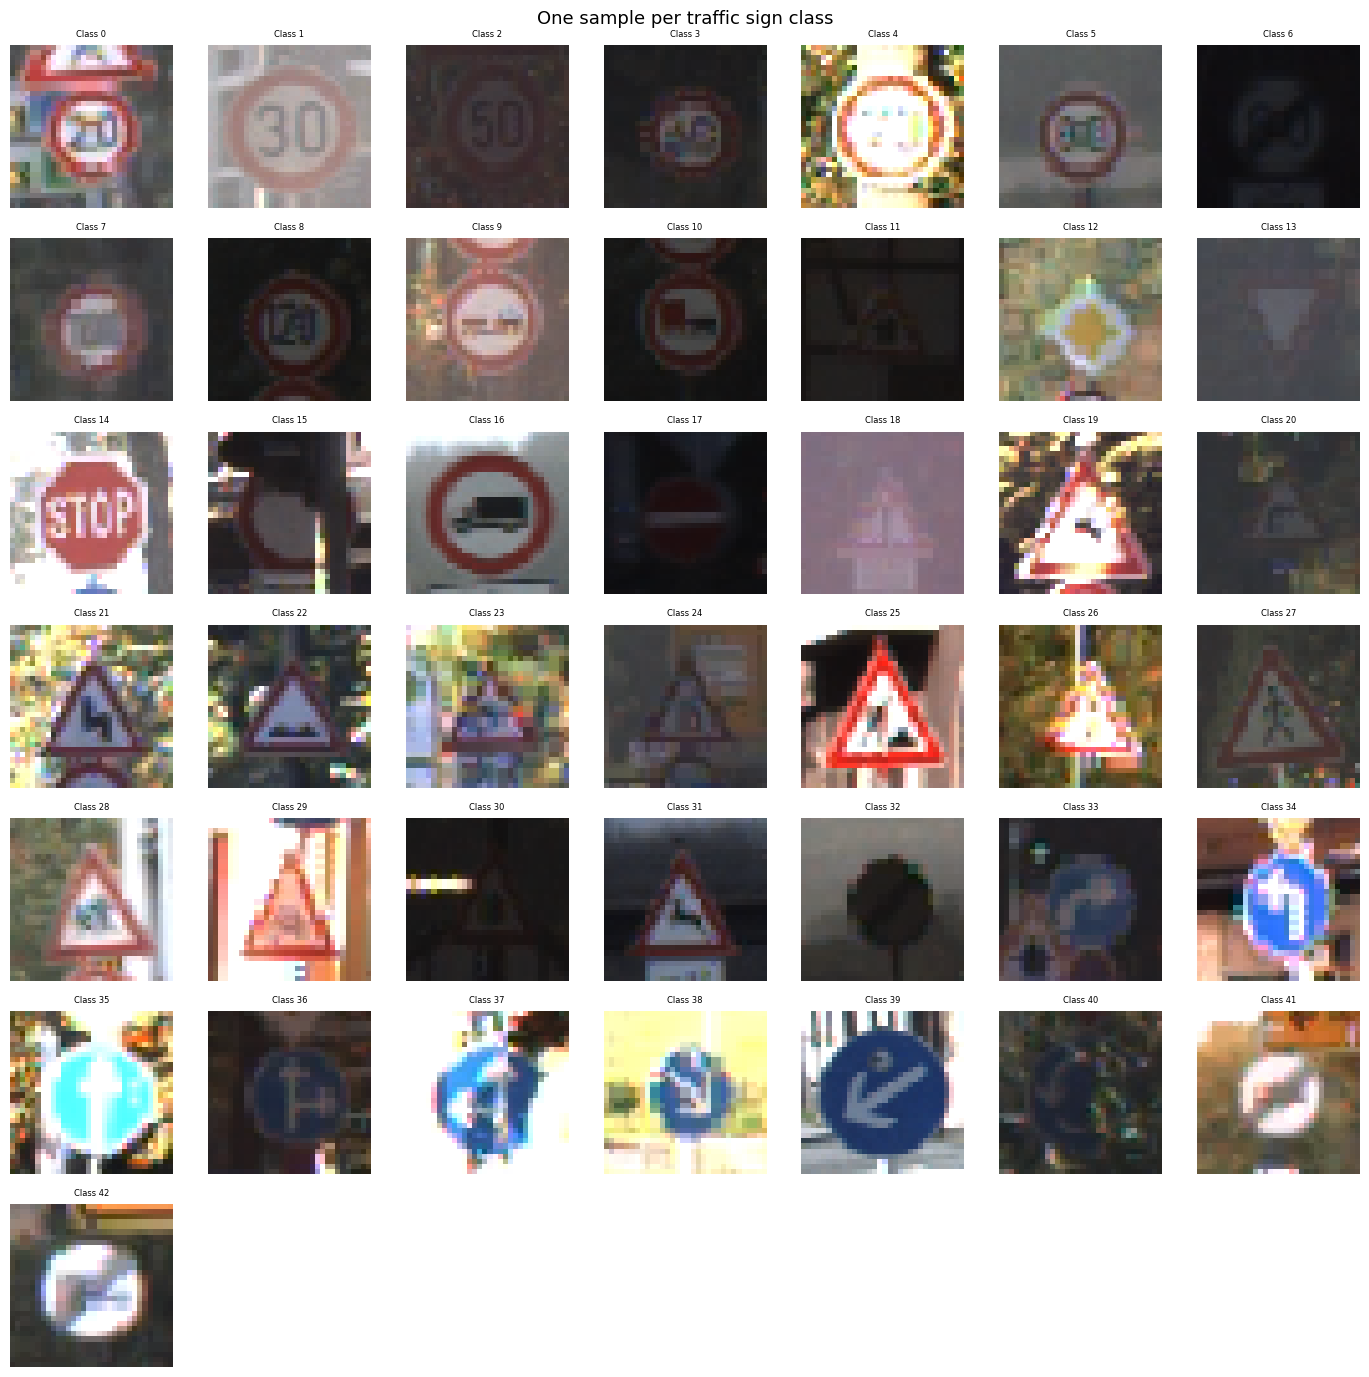

In [10]:
train_path = os.path.join(data_dir, 'Train')
img_dir    = pathlib.Path(train_path)

plt.figure(figsize=(14, 14))
for i in range(NUM_CLASSES):
    plt.subplot(7, 7, i + 1)
    sign = list(img_dir.glob(f'{i}/*'))[0]
    img  = load_img(sign, target_size=IMG_SIZE)
    plt.imshow(img)
    plt.title(f'Class {i}', fontsize=6)
    plt.axis('off')
plt.suptitle('One sample per traffic sign class', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

In [12]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPool2D(2,2),
    
    Conv2D(64,(3,3),activation='relu'),
    MaxPool2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
   

    Flatten(),

    Dense(256,activation='relu'),

    Dropout(0.5),

    Dense(43,activation='softmax')

    
])

D:\AI & DS\Projects\Deep Learning Project\03\traffic_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │          11,051 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 628,843 (2.40 MB)

 Trainable params: 628,843 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [15]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

In [16]:
history=model.fit(datagen.flow(x_train,y_train,batch_size=BATCH_SIZE),
                  validation_data=(x_val,y_val),
                  epochs=EPOCHS,
                 callbacks=callbacks)

Epoch 1/15
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.3801 - loss: 2.0844 - val_accuracy: 0.7475 - val_loss: 0.8164 - learning_rate: 0.0010
Epoch 2/15
858/858 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.7182 - loss: 0.8733 - val_accuracy: 0.9322 - val_loss: 0.2509 - learning_rate: 0.0010
Epoch 3/15
858/858 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8457 - loss: 0.4765 - val_accuracy: 0.9519 - val_loss: 0.1693 - learning_rate: 0.0010
Epoch 4/15
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9040 - loss: 0.3097 - val_accuracy: 0.9738 - val_loss: 0.1047 - learning_rate: 0.0010
Epoch 5/15
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9285 - loss: 0.2308 - val_accuracy: 0.9857 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 6/15
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9424 - loss: 0.1867 - val_accuracy: 0.9804 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 7/15
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9529 - l

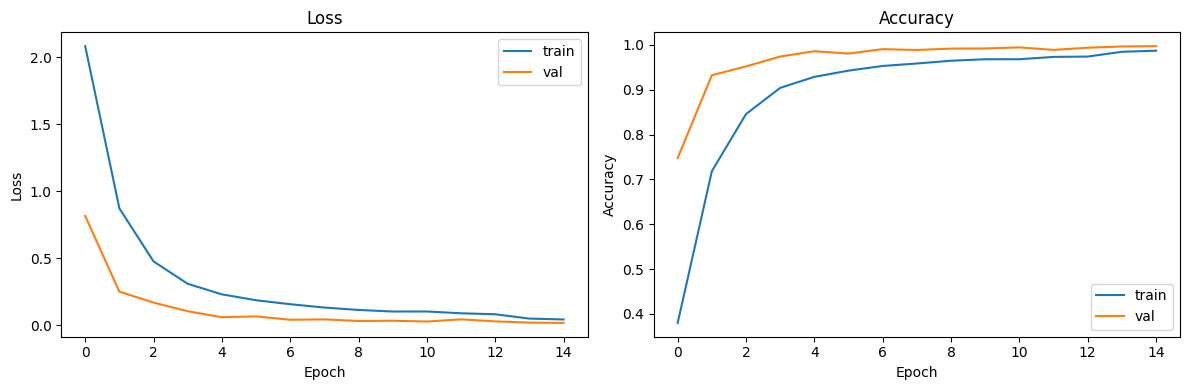

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'training_curves.png'), dpi=150)
plt.show()

In [18]:
score = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {score[0]:.4f}")
print(f'Test Accuracy: {score[1]*100:.2f}%')

Test Loss: 0.0074
Test Accuracy: 99.73%


In [19]:
classes  = pd.read_csv(os.path.join(data_dir, 'labels.csv'))
label_map = dict(zip(classes.iloc[:, 0], classes.iloc[:, 1]))
classes.head()

,ClassId,Name
0,0,Speed limit (20km/h)
1,1,Speed limit (30km/h)
2,2,Speed limit (50km/h)
3,3,Speed limit (60km/h)
4,4,Speed limit (70km/h)


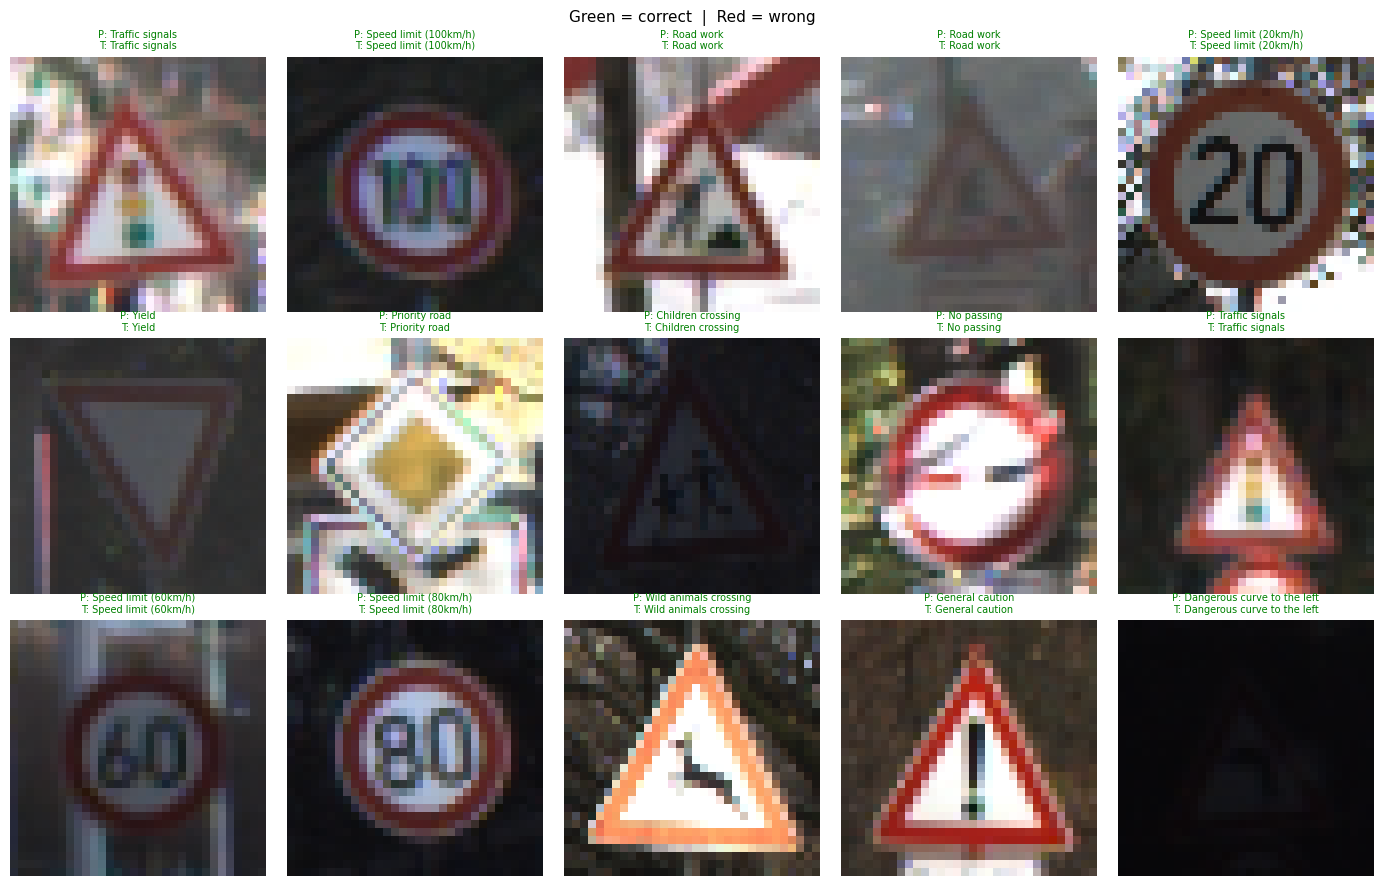

In [20]:
def predict_and_show(n_samples: int = 15):
    """Show n_samples test images with true and predicted labels."""
    indices     = np.random.choice(len(x_test), size=n_samples, replace=False)
    imgs        = x_test[indices]

   
    preds        = model.predict(imgs, verbose=0)
    pred_labels  = np.argmax(preds, axis=1)
    true_labels  = y_test[indices]    

    cols = 5
    rows = (n_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))

    for i, ax in enumerate(axes.flat):
        if i >= n_samples:
            ax.axis('off')
            continue
        ax.imshow(imgs[i])
        pred_name = label_map.get(pred_labels[i], pred_labels[i])
        true_name = label_map.get(true_labels[i], true_labels[i])
        color = 'green' if pred_labels[i] == true_labels[i] else 'red'
        ax.set_title(f'P: {pred_name}\nT: {true_name}', fontsize=7, color=color)
        ax.axis('off')

    plt.suptitle('Green = correct  |  Red = wrong', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(artifacts_dir, 'predictions.png'), dpi=150)
    plt.show()

predict_and_show()

In [21]:
save_path = os.path.join(artifacts_dir, 'traffic_sign_model.keras')
model.save(save_path)
print(f'Model saved to {save_path}')

Model saved to ../artifacts\traffic_sign_model.keras
